In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import Perceptron as SKPerceptron

FEATURES = ['variance', 'skewness', 'curtosis', 'entropy']
raw = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt",
    names=FEATURES + ['label']
)
raw['label'] = raw['label'].astype(int)

In [ ]:
print(f"Shape: {raw.shape[0]} rows x {raw.shape[1]} cols")
print(f"\nMissing values:\n{raw.isnull().sum()}")
print(f"\nClass balance:\n{raw['label'].value_counts(normalize=True).round(3)}")
raw.describe().T

Shape: 1372 rows x 5 cols

Missing values:
variance    0
skewness    0
curtosis    0
entropy     0
label       0
dtype: int64

Class balance:
label
0    0.555
1    0.445
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
label,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000


Plots

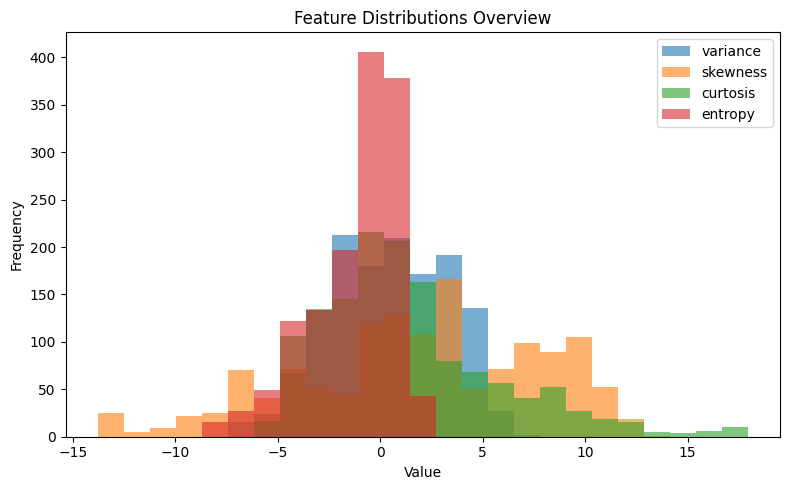

In [ ]:
plt.figure(figsize=(8, 5))
raw[FEATURES].plot(kind='hist', bins=25, alpha=0.6, subplots=False, legend=True, ax=plt.gca())
plt.title("Feature Distributions Overview")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("1_feature_distributions.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()

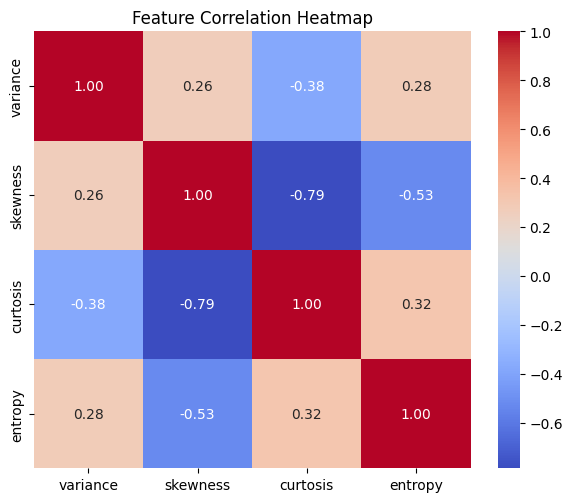

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(raw[FEATURES].corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()

plt.savefig("2_correlation_heatmap.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()

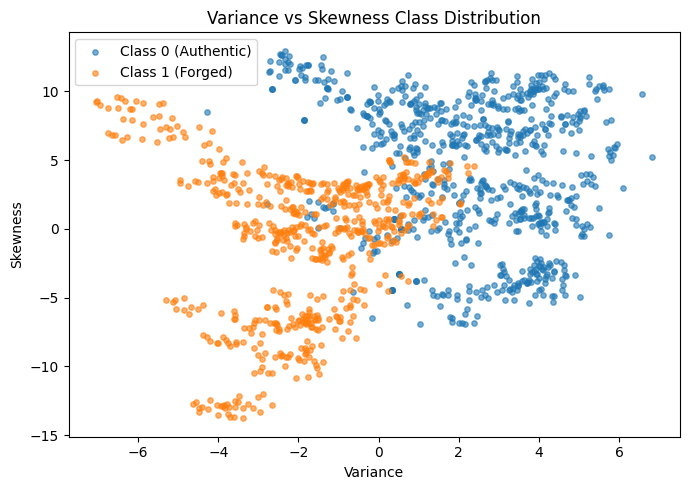

In [ ]:
plt.figure(figsize=(7,5))
for cls, sub in raw.groupby('label'):
    plt.scatter(sub['variance'],sub['skewness'],s=15,alpha=0.6,label=f"Class {cls} ({'Forged' if cls==1 else 'Authentic'})")

plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Variance vs Skewness Class Distribution")
plt.legend()
plt.tight_layout()
plt.savefig("3_variance_vs_skewness_scatter.eps",
            format='eps', dpi=200, bbox_inches='tight')
plt.show()

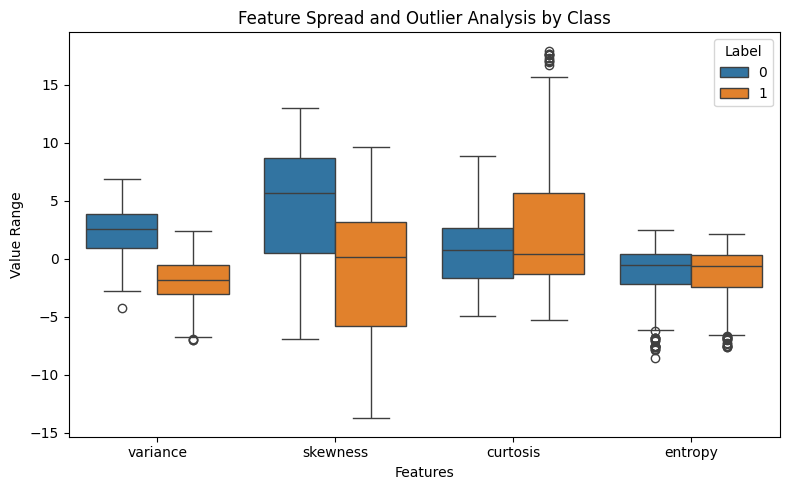

In [ ]:
plt.figure(figsize=(8, 5))
melted = raw.melt(id_vars='label', value_vars=FEATURES)
sns.boxplot(data=melted, x='variable', y='value', hue='label')
plt.title("Feature Spread and Outlier Analysis by Class")
plt.xlabel("Features")
plt.ylabel("Value Range")
plt.legend(title="Label")
plt.tight_layout()

plt.savefig("4_feature_boxplots.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# Preprocessing
X = raw[FEATURES].to_numpy()
y = raw['label'].to_numpy()

mu, sigma = X.mean(axis=0), X.std(axis=0)
X_std = (X - mu) / sigma

X_train, X_test, y_train, y_test = train_test_split(
    X_std, y, test_size=0.2, random_state=7, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 1097 | Test: 275


In [ ]:
# Perceptron
class BinaryPerceptron:
    def __init__(self, lr=0.01, max_epochs=60, seed=7):
        self.lr = lr
        self.max_epochs = max_epochs
        self.rng = np.random.RandomState(seed)
        self.w = None
        self.b = None
        self.log = []

    @staticmethod
    def _step(z):
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y, verbose=True):
        n_features = X.shape[1]
        self.w = self.rng.normal(0, 0.01, n_features)
        self.b = 0.0
        n = len(X)

        for epoch in range(1, self.max_epochs + 1):
            order = self.rng.permutation(n)
            errors = 0
            for i in order:
                xi, yi = X[i], y[i]
                pred = self._step(np.dot(xi, self.w) + self.b)
                delta = self.lr * (yi - pred)
                if delta != 0:
                    self.w += delta * xi
                    self.b += delta
                    errors += 1

            self.log.append({'epoch': epoch, 'errors': errors,
                              'weights': self.w.copy(), 'bias': self.b})

            if verbose and (epoch == 1 or epoch % 10 == 0 or errors == 0):
                print(f"epoch {epoch:2d} | errors {errors:3d} | bias {self.b:+.4f} | w {np.round(self.w,3)}")

            if errors == 0:
                print(f"Converged at epoch {epoch}.")
                break
        return self

    def predict(self, X):
        return self._step(np.dot(X, self.w) + self.b)

model = BinaryPerceptron(lr=0.01, max_epochs=60).fit(X_train, y_train)
history = pd.DataFrame(model.log)
history.head()

epoch  1 | errors  49 | bias -0.0300 | w [-0.055 -0.05  -0.067 -0.013]
epoch 10 | errors  17 | bias -0.0400 | w [-0.154 -0.158 -0.115 -0.007]
epoch 20 | errors  21 | bias -0.0600 | w [-0.175 -0.183 -0.149 -0.003]
epoch 30 | errors  14 | bias -0.0900 | w [-0.199 -0.2   -0.168 -0.007]
epoch 40 | errors  15 | bias -0.0900 | w [-0.212 -0.204 -0.212 -0.006]
epoch 50 | errors  19 | bias -0.1000 | w [-0.242 -0.249 -0.175 -0.016]
epoch 60 | errors  10 | bias -0.1000 | w [-0.252 -0.247 -0.208  0.005]


,epoch,errors,weights,bias
0,1,49,"[-0.054987709825808195, -0.05004546457319241, ...",-0.03
1,2,38,"[-0.08423566974438304, -0.11142986354536841, -...",-0.03
2,3,20,"[-0.0837587765440027, -0.10865770461288264, -0...",-0.03
3,4,27,"[-0.12093246336850824, -0.13270488263177319, -...",-0.04
4,5,14,"[-0.12199005990364925, -0.11801794574542239, -...",-0.04


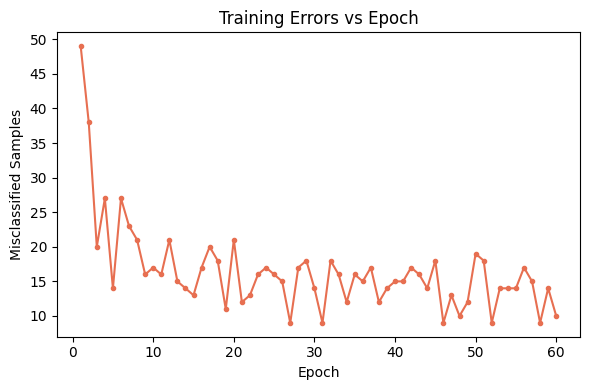

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history['epoch'], history['errors'], color='#e76f51', marker='o', ms=3)
plt.title("Training Errors vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.tight_layout()

plt.savefig("7_training_errors_vs_epoch.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()

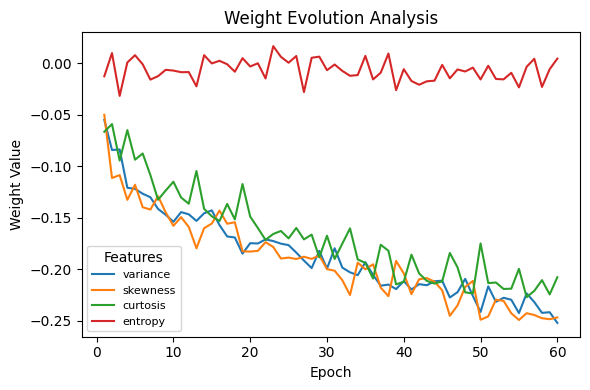

In [ ]:
plt.figure(figsize=(6, 4))
W = np.vstack(history['weights'])
for j, feat in enumerate(FEATURES):
    plt.plot(history['epoch'], W[:, j], label=feat)

plt.title("Weight Evolution Analysis")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend(fontsize=8, title="Features")
plt.tight_layout()

plt.savefig("8_weight_evolution.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()

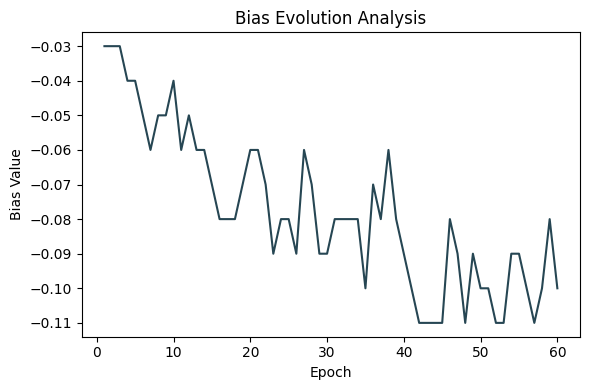

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history['epoch'], history['bias'], color='#264653')
plt.title("Bias Evolution Analysis")
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.tight_layout()

plt.savefig("9_bias_evolution.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()

               precision    recall  f1-score   support

Authentic (0)       0.97      0.98      0.97       153
   Forged (1)       0.97      0.96      0.97       122

     accuracy                           0.97       275
    macro avg       0.97      0.97      0.97       275
 weighted avg       0.97      0.97      0.97       275



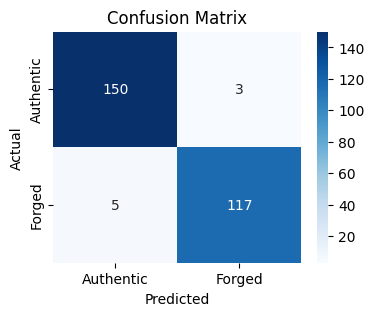

In [ ]:
# Evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Authentic (0)', 'Forged (1)']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Authentic', 'Forged'], yticklabels=['Authentic', 'Forged'])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()

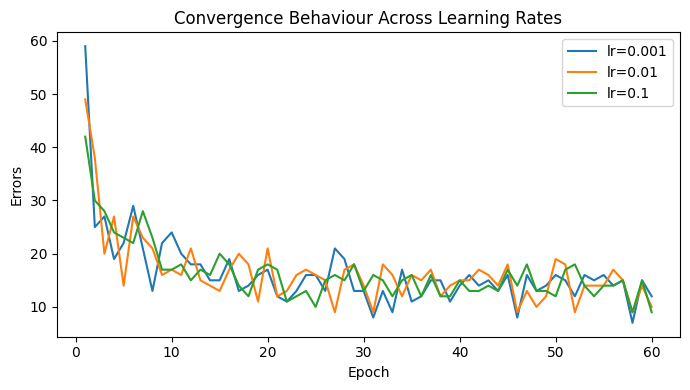

In [ ]:
# learning rate comparison
rates = [0.001, 0.01, 0.1]
plt.figure(figsize=(7, 4))

for lr in rates:
    m = BinaryPerceptron(lr=lr, max_epochs=60).fit(X_train, y_train, verbose=False)
    errs = pd.DataFrame(m.log)['errors']
    plt.plot(range(1, len(errs)+1), errs, label=f"lr={lr}")

plt.title("Convergence Behaviour Across Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Errors")
plt.legend()
plt.tight_layout()

plt.savefig("10_learning_rate_comparison.eps", format='eps', dpi=200, bbox_inches='tight')

plt.show()

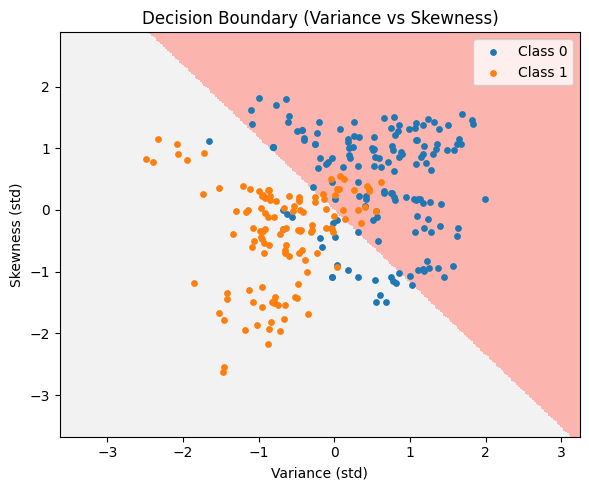



      PERFORMANCE COMPARISON EVAL         
Scratch model accuracy : 0.9709
Sklearn Perceptron acc : 0.9455


In [ ]:
from sklearn.metrics.pairwise import paired_cosine_distances

#  DECISION BOUNDARY PLOT
two_feat = ['variance', 'skewness']
Xv = raw[two_feat].to_numpy()
Xv = (Xv - Xv.mean(0)) / Xv.std(0)

y_target = raw['label'].to_numpy() if 'label' in raw.columns else raw['class'].to_numpy()

Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(Xv, y_target, test_size=0.2, random_state=7, stratify=y_target)

# Fit scratch model on 2 features
m2 = BinaryPerceptron(lr=0.01, max_epochs=60).fit(Xv_tr, yv_tr, verbose=False)

x_min, x_max = Xv[:,0].min()-1, Xv[:,0].max()+1
y_min, y_max = Xv[:,1].min()-1, Xv[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid_pred = m2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6, 5))

plt.pcolormesh(xx, yy, grid_pred, cmap='Pastel1', shading='auto')

# Plot test points
for cls, sub in zip([0, 1], [Xv_te[yv_te==0], Xv_te[yv_te==1]]):
    plt.scatter(sub[:,0], sub[:,1], s=15, label=f"Class {cls}")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel("Variance (std)")
plt.ylabel("Skewness (std)")
plt.title("Decision Boundary (Variance vs Skewness)")
plt.legend()
plt.tight_layout()

plt.savefig("11_decision_boundary.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()


# SKLEARN MODEL COMPARISON
sk = SKPerceptron(max_iter=60, eta0=0.01, random_state=7).fit(X_train, y_train)

scratch_acc = (model.predict(X_test) == y_test).mean()
sklearn_acc = sk.score(X_test, y_test)

print("\n")
print("      PERFORMANCE COMPARISON EVAL         ")
print(f"Scratch model accuracy : {scratch_acc:.4f}")
print(f"Sklearn Perceptron acc : {sklearn_acc:.4f}")

Additional Task

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, n_inputs, lr=0.1):
        self.lr = lr
        self.w = np.zeros(n_inputs)
        self.b = 0.0

    def net_input(self, x):
        return np.dot(x, self.w) + self.b

    def predict(self, x):
        return 1 if self.net_input(x) >= 0 else 0

    def train(self, X, y, epochs=20):
        history = [{'w': self.w.copy(), 'b': self.b, 'epoch': 0, 'sample': 'init'}]

        for epoch in range(1, epochs + 1):
            errors = 0

            for xi, target in zip(X, y):
                pred = self.predict(xi)
                error = target - pred

                if error:
                    self.w += self.lr * error * xi
                    self.b += self.lr * error
                    errors += 1

                    history.append({
                        'w': self.w.copy(),
                        'b': self.b,
                        'epoch': epoch,
                        'sample': tuple(xi.astype(int))
                    })

            if errors == 0:
                print(f"Converged in {epoch} epochs.")
                break
        else:
            print("Maximum epochs reached.")

        return history


def print_weight_table(history, gate):
    print(f"\n{gate} Gate - Weight Updates")
    print("-" * 58)
    print(f"{'Upd':>3} {'Epoch':>5} {'Sample':>10} {'Weights':>18} {'Bias':>8}")
    print("-" * 58)

    for i, h in enumerate(history):
        print(f"{i:>3} {h['epoch']:>5} {str(h['sample']):>10} "
              f"{np.array2string(h['w'], precision=2):>18} {h['b']:>8.2f}")

In [ ]:
def plot_boundaries_2d(history, X, y, gate):

    cols = 4
    rows = int(np.ceil(len(history) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.5*rows))
    axes = np.array(axes).ravel()

    x = np.linspace(-0.5, 1.5, 200)

    for i, h in enumerate(history):

        ax = axes[i]
        w, b = h['w'], h['b']

        for xi, target in zip(X, y):
            ax.scatter(
                xi[0], xi[1],
                c='green' if target else 'red',
                marker='o' if target else 's',
                s=120,
                edgecolors='k'
            )

        if h['sample'] != 'init':
            ax.scatter(
                h['sample'][0], h['sample'][1],
                s=350,
                facecolors='none',
                edgecolors='blue',
                linewidth=2
            )

        if abs(w[1]) > 1e-9:
            y_line = -(w[0]*x + b)/w[1]
            ax.plot(x, y_line, 'k')
        elif abs(w[0]) > 1e-9:
            ax.axvline(-b/w[0], color='k')

        ax.set_xlim(-0.5,1.5)
        ax.set_ylim(-0.5,1.5)
        ax.set_title(f"Step {i}")
        ax.grid(True, alpha=0.3)

    for ax in axes[len(history):]:
        ax.axis('off')

    plt.suptitle(f"{gate} Gate")
    plt.tight_layout()
    plt.show()


def plot_boundaries_1d(history, X, y, gate):

    cols = 4
    rows = int(np.ceil(len(history) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 2.5*rows))
    axes = np.array(axes).ravel()

    for i, h in enumerate(history):

        ax = axes[i]
        w = h['w'][0]
        b = h['b']

        for xi, target in zip(X, y):
            ax.scatter(
                xi[0], 0,
                c='green' if target else 'red',
                s=180,
                edgecolors='k'
            )

        if h['sample'] != 'init':
            ax.scatter(
                h['sample'][0], 0,
                s=420,
                facecolors='none',
                edgecolors='blue',
                linewidth=2
            )

        if abs(w) > 1e-9:
            ax.axvline(-b/w, color='k')

        ax.set_xlim(-0.5,1.5)
        ax.set_ylim(-1,1)
        ax.set_yticks([])
        ax.set_title(f"Step {i}")
        ax.grid(True, alpha=0.3)

    for ax in axes[len(history):]:
        ax.axis('off')

    plt.suptitle(f"{gate} Gate")
    plt.tight_layout()
    plt.show()

Converged in 4 epochs.

AND Gate - Weight Updates
----------------------------------------------------------
Upd Epoch     Sample            Weights     Bias
----------------------------------------------------------
  0     0       init            [0. 0.]     0.00
  1     1 (np.int64(0), np.int64(0))            [0. 0.]    -0.10
  2     1 (np.int64(1), np.int64(1))          [0.1 0.1]     0.00
  3     2 (np.int64(0), np.int64(0))          [0.1 0.1]    -0.10
  4     2 (np.int64(0), np.int64(1))          [0.1 0. ]    -0.20
  5     2 (np.int64(1), np.int64(1))          [0.2 0.1]    -0.10
  6     3 (np.int64(0), np.int64(1))          [0.2 0. ]    -0.20
  7     3 (np.int64(1), np.int64(0))          [0.1 0. ]    -0.30
  8     3 (np.int64(1), np.int64(1))          [0.2 0.1]    -0.20

Final weights: [0.2 0.1], Final bias: -0.20




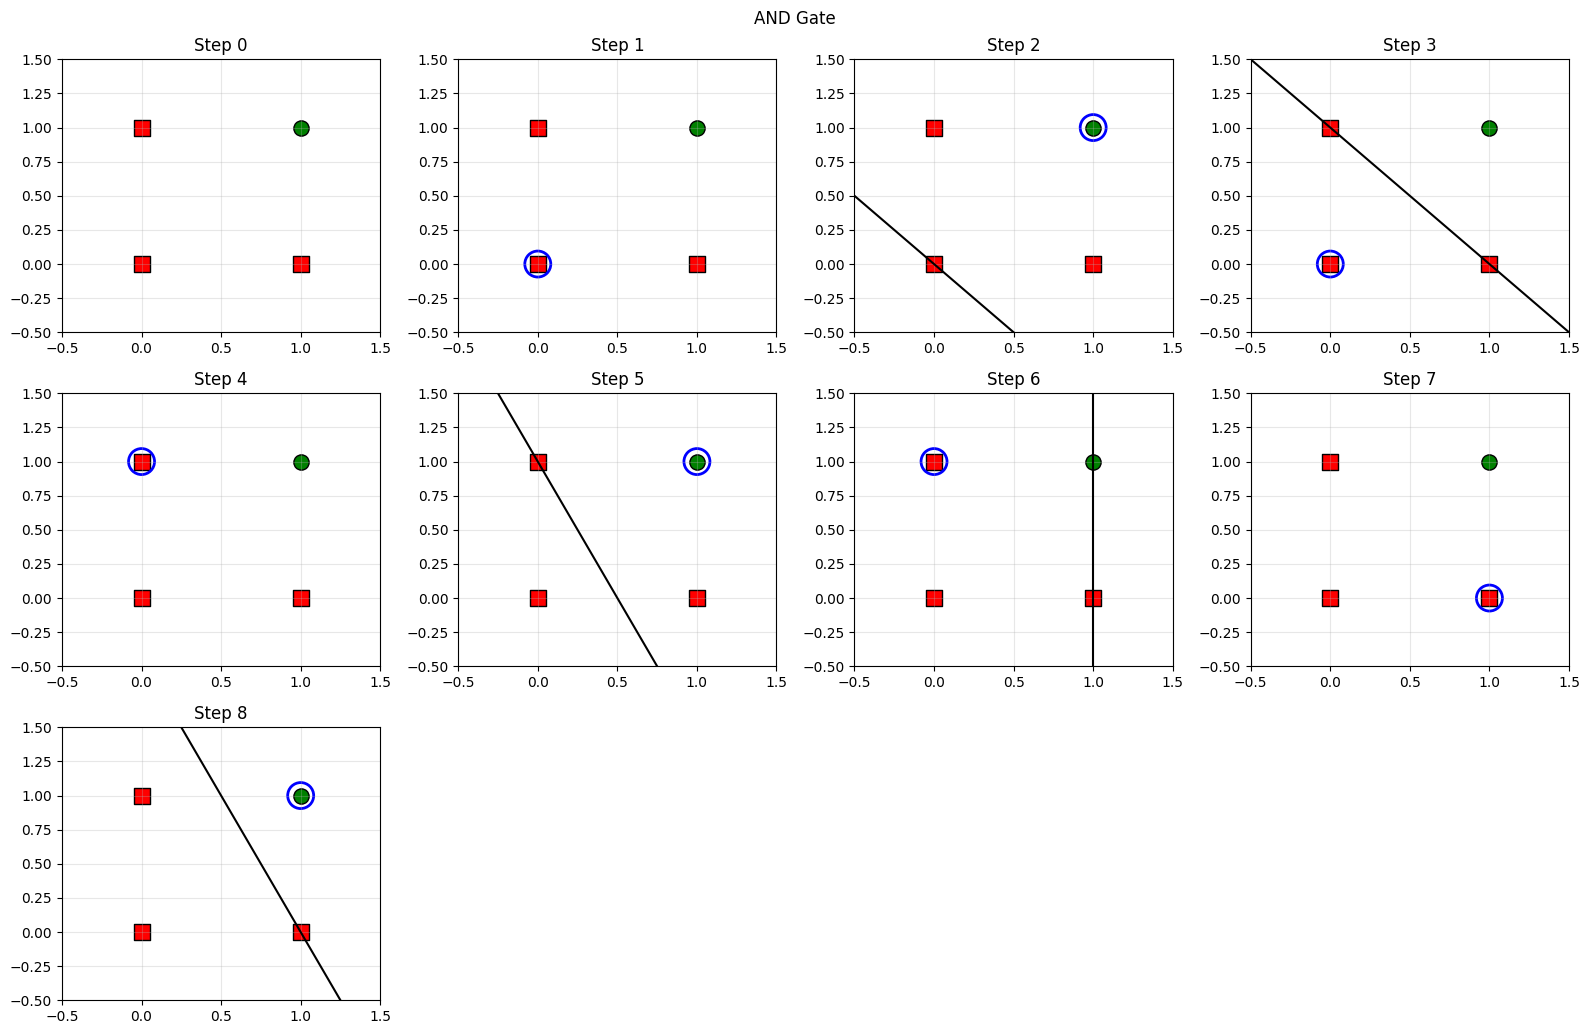



Final predictions - AND gate
  x=[0 0], target=0, predicted=0
  x=[0 1], target=0, predicted=0
  x=[1 0], target=0, predicted=0
  x=[1 1], target=1, predicted=1


In [ ]:
#And gate
X2 = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])

p_and = Perceptron(n_inputs=2, lr=0.1)
history_and = p_and.train(X2, y_and)
print_weight_table(history_and, "AND")
print(f"\nFinal weights: {p_and.w}, Final bias: {p_and.b:.2f}")

print("\n")
plot_boundaries_2d(history_and, X2, y_and, "AND")

print("\n")
print("Final predictions - AND gate")
for xi, target in zip(X2, y_and):
    print(f"  x={xi}, target={target}, predicted={p_and.predict(xi)}")


Converged in 4 epochs.

OR Gate - Weight Updates
----------------------------------------------------------
Upd Epoch     Sample            Weights     Bias
----------------------------------------------------------
  0     0       init            [0. 0.]     0.00
  1     1 (np.int64(0), np.int64(0))            [0. 0.]    -0.10
  2     1 (np.int64(0), np.int64(1))          [0.  0.1]     0.00
  3     2 (np.int64(0), np.int64(0))          [0.  0.1]    -0.10
  4     2 (np.int64(1), np.int64(0))          [0.1 0.1]     0.00
  5     3 (np.int64(0), np.int64(0))          [0.1 0.1]    -0.10

Final weights: [0.1 0.1], Final bias: -0.10




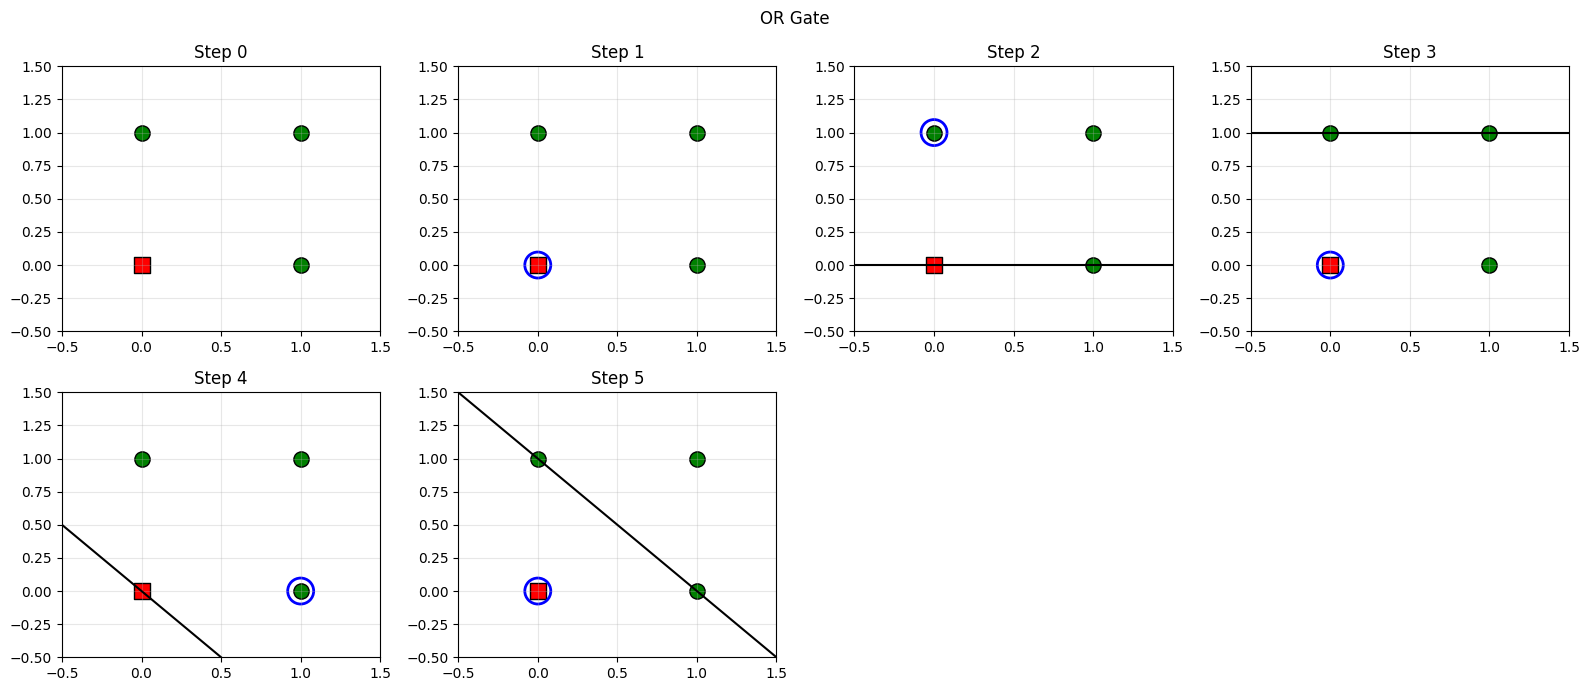



Final predictions - OR gate
  x=[0 0], target=0, predicted=0
  x=[0 1], target=1, predicted=1
  x=[1 0], target=1, predicted=1
  x=[1 1], target=1, predicted=1


In [ ]:
#or gate
y_or = np.array([0,1,1,1])

p_or = Perceptron(n_inputs=2, lr=0.1)
history_or = p_or.train(X2, y_or)
print_weight_table(history_or, "OR")
print(f"\nFinal weights: {p_or.w}, Final bias: {p_or.b:.2f}")

print("\n")
plot_boundaries_2d(history_or, X2, y_or, "OR")

print("\n")
print("Final predictions - OR gate")
for xi, target in zip(X2, y_or):
    print(f"  x={xi}, target={target}, predicted={p_or.predict(xi)}")


Converged in 3 epochs.

NOT Gate - Weight Updates
----------------------------------------------------------
Upd Epoch     Sample            Weights     Bias
----------------------------------------------------------
  0     0       init               [0.]     0.00
  1     1 (np.int64(1),)             [-0.1]    -0.10
  2     2 (np.int64(0),)             [-0.1]     0.00

Final weight: [-0.1], Final bias: 0.00




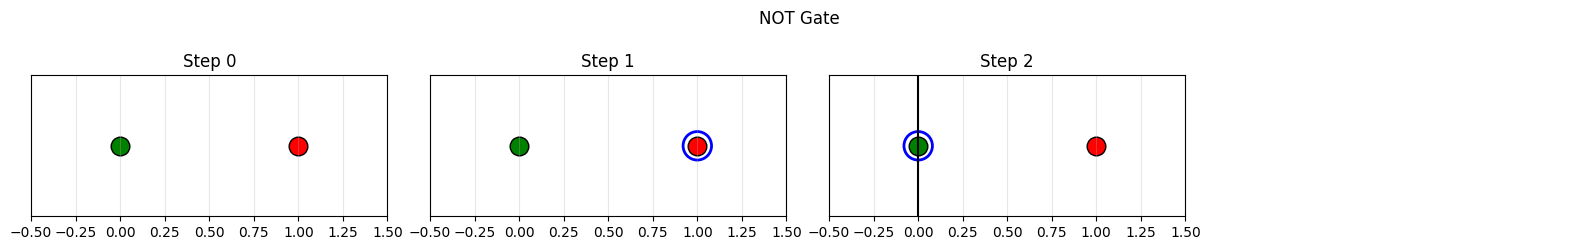



Final predictions - NOT gate
  x=[0], target=1, predicted=1
  x=[1], target=0, predicted=0


In [ ]:
#not gate
X1 = np.array([[0],[1]])
y_not = np.array([1,0])

p_not = Perceptron(n_inputs=1, lr=0.1)
history_not = p_not.train(X1, y_not)
print_weight_table(history_not, "NOT")
print(f"\nFinal weight: {p_not.w}, Final bias: {p_not.b:.2f}")

print("\n")
plot_boundaries_1d(history_not, X1, y_not, "NOT")

print("\n")
print("Final predictions - NOT gate")
for xi, target in zip(X1, y_not):
    print(f"  x={xi}, target={target}, predicted={p_not.predict(xi)}")



Additional Task 2


In [1]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, n_inputs, lr=0.1):
        self.lr = lr
        self.w = np.zeros(n_inputs)   # one weight per input feature
        self.b = 0.0                  # bias

    def net_input(self, x):
        return np.dot(x, self.w) + self.b

    def predict(self, x):
        return 1 if self.net_input(x) >= 0 else 0

    def train(self, X, y, epochs=20):
        history = [{'w': self.w.copy(), 'b': self.b, 'epoch': 0, 'sample': None}]
        for epoch in range(1, epochs + 1):
            n_errors = 0
            for i, (xi, target) in enumerate(zip(X, y)):
                pred = self.predict(xi)
                error = target - pred
                if error != 0:
                    self.w = self.w + self.lr * error * xi
                    self.b = self.b + self.lr * error
                    n_errors += 1
                    history.append({'w': self.w.copy(), 'b': self.b,
                                     'epoch': epoch,
                                     'sample': tuple(int(v) for v in xi)})
            if n_errors == 0:
                print(f"Converged after {epoch} epochs, {len(history)-1} weight updates.")
                break
        else:
            print(f"Did not converge within {epochs} epochs "
                  f"({len(history)-1} weight updates made).")
        return history


def print_weight_table(history, gate_name):
    print(f"\nWeight updates for {gate_name} gate")
    print("-" * 60)
    print(f"{'Update':>6} | {'Epoch':>5} | {'Sample':>10} | {'Weights':>18} | {'Bias':>8}")
    print("-" * 60)
    for k, h in enumerate(history):
        sample = h['sample'] if h['sample'] is not None else 'init'
        w_str = np.array2string(h['w'], precision=2)
        print(f"{k:>6} | {str(h['epoch']):>5} | {str(sample):>10} | {w_str:>18} | {h['b']:>8.2f}")

In [2]:
def plot_boundaries_2d(history, X, y, gate_name):
    n = len(history)
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.6 * rows))
    axes = np.array(axes).reshape(-1)

    xx = np.linspace(-0.5, 1.5, 200)

    for k, h in enumerate(history):
        ax = axes[k]
        w, b = h['w'], h['b']

        for xi, target in zip(X, y):
            marker = 'o' if target == 1 else 's'
            color = 'tab:green' if target == 1 else 'tab:red'
            ax.scatter(*xi, marker=marker, color=color, s=140, edgecolor='k', zorder=3)

        if h['sample'] is not None:
            ax.scatter(*h['sample'], s=400, facecolors='none',
                       edgecolors='blue', linewidths=2, zorder=4)

        if abs(w[1]) > 1e-9:
            yy = -(w[0] * xx + b) / w[1]
            ax.plot(xx, yy, 'k-', linewidth=2)
        elif abs(w[0]) > 1e-9:
            x_vert = -b / w[0]
            ax.axvline(x_vert, color='k', linewidth=2)

        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.5, 1.5)
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        title = f"Update {k}" if k > 0 else "Initial"
        ax.set_title(f"{title}\nw={np.round(w,2)}, b={b:.2f}", fontsize=9)
        ax.grid(alpha=0.3)

    for j in range(n, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f"{gate_name} gate: decision boundary after each weight update", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

Did not converge within 6 epochs (22 weight updates made).

Weight updates for XOR gate
------------------------------------------------------------
Update | Epoch |     Sample |            Weights |     Bias
------------------------------------------------------------
     0 |     0 |       init |            [0. 0.] |     0.00
     1 |     1 |     (0, 0) |            [0. 0.] |    -0.10
     2 |     1 |     (0, 1) |          [0.  0.1] |     0.00
     3 |     1 |     (1, 1) |        [-0.1  0. ] |    -0.10
     4 |     2 |     (0, 1) |        [-0.1  0.1] |     0.00
     5 |     2 |     (1, 0) |          [0.  0.1] |     0.10
     6 |     2 |     (1, 1) |        [-0.1  0. ] |     0.00
     7 |     3 |     (0, 0) |        [-0.1  0. ] |    -0.10
     8 |     3 |     (0, 1) |        [-0.1  0.1] |     0.00
     9 |     3 |     (1, 0) |          [0.  0.1] |     0.10
    10 |     3 |     (1, 1) |        [-0.1  0. ] |     0.00
    11 |     4 |     (0, 0) |        [-0.1  0. ] |    -0.10
    12 |  

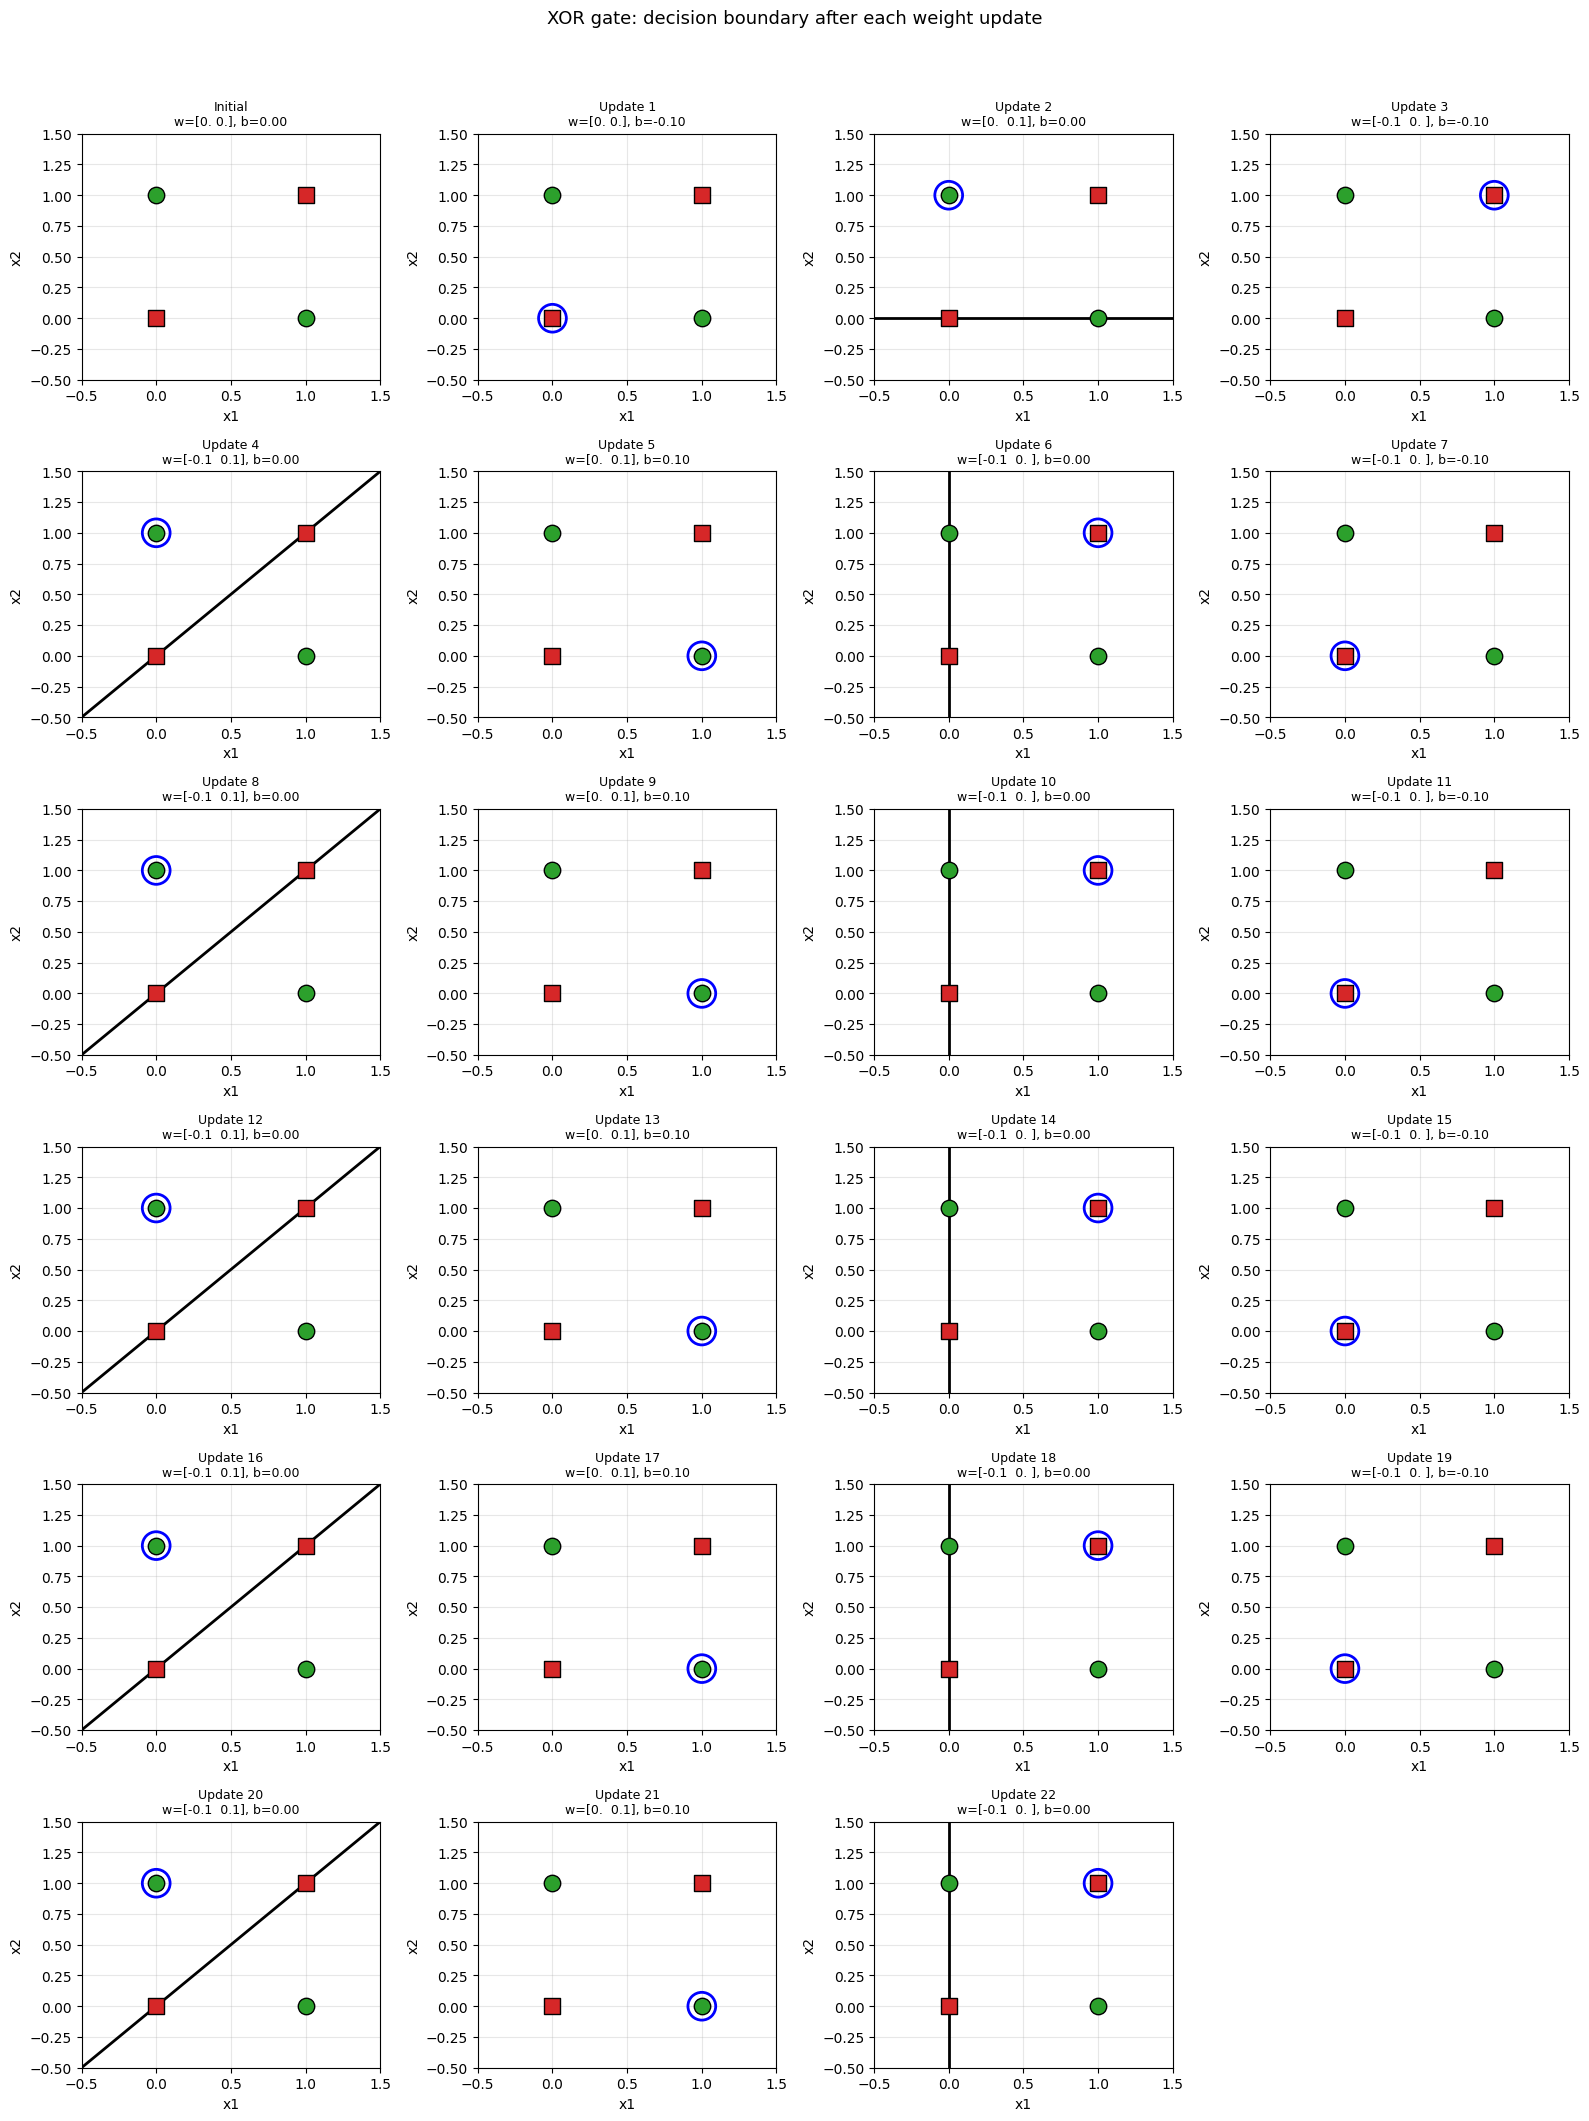



Predictions using the weights at the point training was stopped:
  x=[0 0], target=0, predicted=1
  x=[0 1], target=1, predicted=1
  x=[1 0], target=1, predicted=0
  x=[1 1], target=0, predicted=0
some point in the XOR table is always wrong.


In [3]:
#XOR
X2 = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0,1,1,0])

p_xor = Perceptron(n_inputs=2, lr=0.1)
history_xor = p_xor.train(X2, y_xor, epochs=6)
print_weight_table(history_xor, "XOR")
print(f"\nWeights after last update shown: {p_xor.w}, bias: {p_xor.b:.2f}")

print("\n")
plot_boundaries_2d(history_xor, X2, y_xor, "XOR")

print("\n")
print("Predictions using the weights at the point training was stopped:")
for xi, target in zip(X2, y_xor):
    print(f"  x={xi}, target={target}, predicted={p_xor.predict(xi)}")
print("some point in the XOR table is always wrong.")

In [4]:
p_long = Perceptron(n_inputs=2, lr=0.1)
history_long = p_long.train(X2, y_xor, epochs=50)

from collections import defaultdict
by_epoch = defaultdict(list)
for entry in history_long[1:]:
    by_epoch[entry['epoch']].append((tuple(np.round(entry['w'], 3)), round(entry['b'], 3)))

epochs = sorted(by_epoch.keys())
cycle_start = next(e for e in epochs[:-1] if by_epoch[e] == by_epoch.get(e + 1))

print(f"Total epochs run: {epochs[-1]}, total weight updates: {len(history_long)-1}")
for (w, b) in by_epoch[cycle_start]:
    print(f"  w={w}, b={b}")

Did not converge within 50 epochs (198 weight updates made).
Total epochs run: 50, total weight updates: 198
  w=(np.float64(-0.1), np.float64(0.0)), b=-0.1
  w=(np.float64(-0.1), np.float64(0.1)), b=0.0
  w=(np.float64(0.0), np.float64(0.1)), b=0.1
  w=(np.float64(-0.1), np.float64(0.0)), b=0.0
